In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
print("Current working directory:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Current working directory:
e:\sam\Infosys intern\Prognos

Files in this folder:
['.venv', 'best_gru_model.pth', 'best_lstm_model.pth', 'dashboard.py', 'ensemble_metrics.csv', 'feature_cols.pkl', 'gru_evaluation_metrics.csv', 'gru_loss_history.csv', 'lstm_evaluation_metrics.csv', 'lstm_loss_history.csv', 'main.ipynb', 'merged_train.csv', 'model_comparison.csv', 'RUL_FD001.txt', 'RUL_FD002.txt', 'RUL_FD003.txt', 'RUL_FD004.txt', 'scaler.pkl', 'test_FD001.txt', 'test_FD002.txt', 'test_FD003.txt', 'test_FD004.txt', 'train_FD001.txt', 'train_FD002.txt', 'train_FD003.txt', 'train_FD004.txt', 'venv', 'X_train_seq.npy', 'X_val_seq.npy', 'y_train_seq.npy', 'y_val_seq.npy']


In [3]:
# Column names for CMAPSS dataset
columns = (
    ['engine_id', 'cycle'] +
    [f'op_setting_{i}' for i in range(1, 4)] +
    [f'sensor_{i}' for i in range(1, 22)]
)

print("Total columns:", len(columns))
print(columns[:10])

Total columns: 26
['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5']


In [4]:
train_files = [
    'train_FD001.txt',
    'train_FD002.txt',
    'train_FD003.txt',
    'train_FD004.txt'
]

train_dfs = []

for file in train_files:
    df = pd.read_csv(file, sep=' ', header=None)
    
    # Remove extra empty columns (last 2 columns are blank)
    df = df.dropna(axis=1)
    
    # Assign column names
    df.columns = columns
    
    # Create source file column
    df['source_file'] = file
    
    # Create UNIQUE engine ID
    df['engine_uid'] = df['source_file'] + "_" + df['engine_id'].astype(str)
    
    train_dfs.append(df)

# Merge all
train_df = pd.concat(train_dfs, ignore_index=True)

print("Train shape:", train_df.shape)
print("Unique engines:", train_df['engine_uid'].nunique())
train_df.head()

Train shape: (160359, 28)
Unique engines: 709


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,source_file,engine_uid
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,train_FD001.txt,train_FD001.txt_1
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,train_FD001.txt,train_FD001.txt_1
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,train_FD001.txt,train_FD001.txt_1
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,train_FD001.txt,train_FD001.txt_1
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,train_FD001.txt,train_FD001.txt_1


In [5]:
print("Missing values per column:")
print(train_df.isnull().sum())

print("\nAny missing values in dataset?", train_df.isnull().values.any())

Missing values per column:
engine_id       0
cycle           0
op_setting_1    0
op_setting_2    0
op_setting_3    0
sensor_1        0
sensor_2        0
sensor_3        0
sensor_4        0
sensor_5        0
sensor_6        0
sensor_7        0
sensor_8        0
sensor_9        0
sensor_10       0
sensor_11       0
sensor_12       0
sensor_13       0
sensor_14       0
sensor_15       0
sensor_16       0
sensor_17       0
sensor_18       0
sensor_19       0
sensor_20       0
sensor_21       0
source_file     0
engine_uid      0
dtype: int64

Any missing values in dataset? False


In [6]:
# Step 1: Get max cycle per engine
max_cycle = train_df.groupby('engine_uid')['cycle'].max().reset_index()
max_cycle.columns = ['engine_uid', 'max_cycle']

# Step 2: Merge back
train_df = train_df.merge(max_cycle, on='engine_uid')

# Step 3: Compute RUL
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

# Step 4: Drop max_cycle (not needed anymore)
train_df = train_df.drop(columns=['max_cycle'])

# Preview
train_df[['engine_uid', 'cycle', 'RUL']].head(10)

,engine_uid,cycle,RUL
0,train_FD001.txt_1,1,191
1,train_FD001.txt_1,2,190
2,train_FD001.txt_1,3,189
3,train_FD001.txt_1,4,188
4,train_FD001.txt_1,5,187
5,train_FD001.txt_1,6,186
6,train_FD001.txt_1,7,185
7,train_FD001.txt_1,8,184
8,train_FD001.txt_1,9,183
9,train_FD001.txt_1,10,182


In [7]:
train_df.groupby('engine_uid')['RUL'].max().head()

engine_uid
train_FD001.txt_1      191
train_FD001.txt_10     221
train_FD001.txt_100    199
train_FD001.txt_11     239
train_FD001.txt_12     169
Name: RUL, dtype: int64

In [8]:
# Clip RUL
train_df['RUL'] = train_df['RUL'].clip(upper=125)

# Check distribution
print("Max RUL after clipping:", train_df['RUL'].max())
train_df['RUL'].describe()

Max RUL after clipping: 125


count    160359.000000
mean         90.182029
std          41.241036
min           0.000000
25%          56.000000
50%         113.000000
75%         125.000000
max         125.000000
Name: RUL, dtype: float64

In [9]:
# Drop sensor_16
train_df = train_df.drop(columns=['sensor_16'])

print("Shape after dropping sensor_16:", train_df.shape)

Shape after dropping sensor_16: (160359, 28)


In [10]:
print(len(train_df.columns))
print(train_df.columns.tolist())

28
['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'source_file', 'engine_uid', 'RUL']


In [11]:
# Define feature columns
feature_cols = [col for col in train_df.columns if col.startswith('op_setting') or col.startswith('sensor')]

print("Total features:", len(feature_cols))
print(feature_cols[:10])

Total features: 23
['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7']


In [12]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


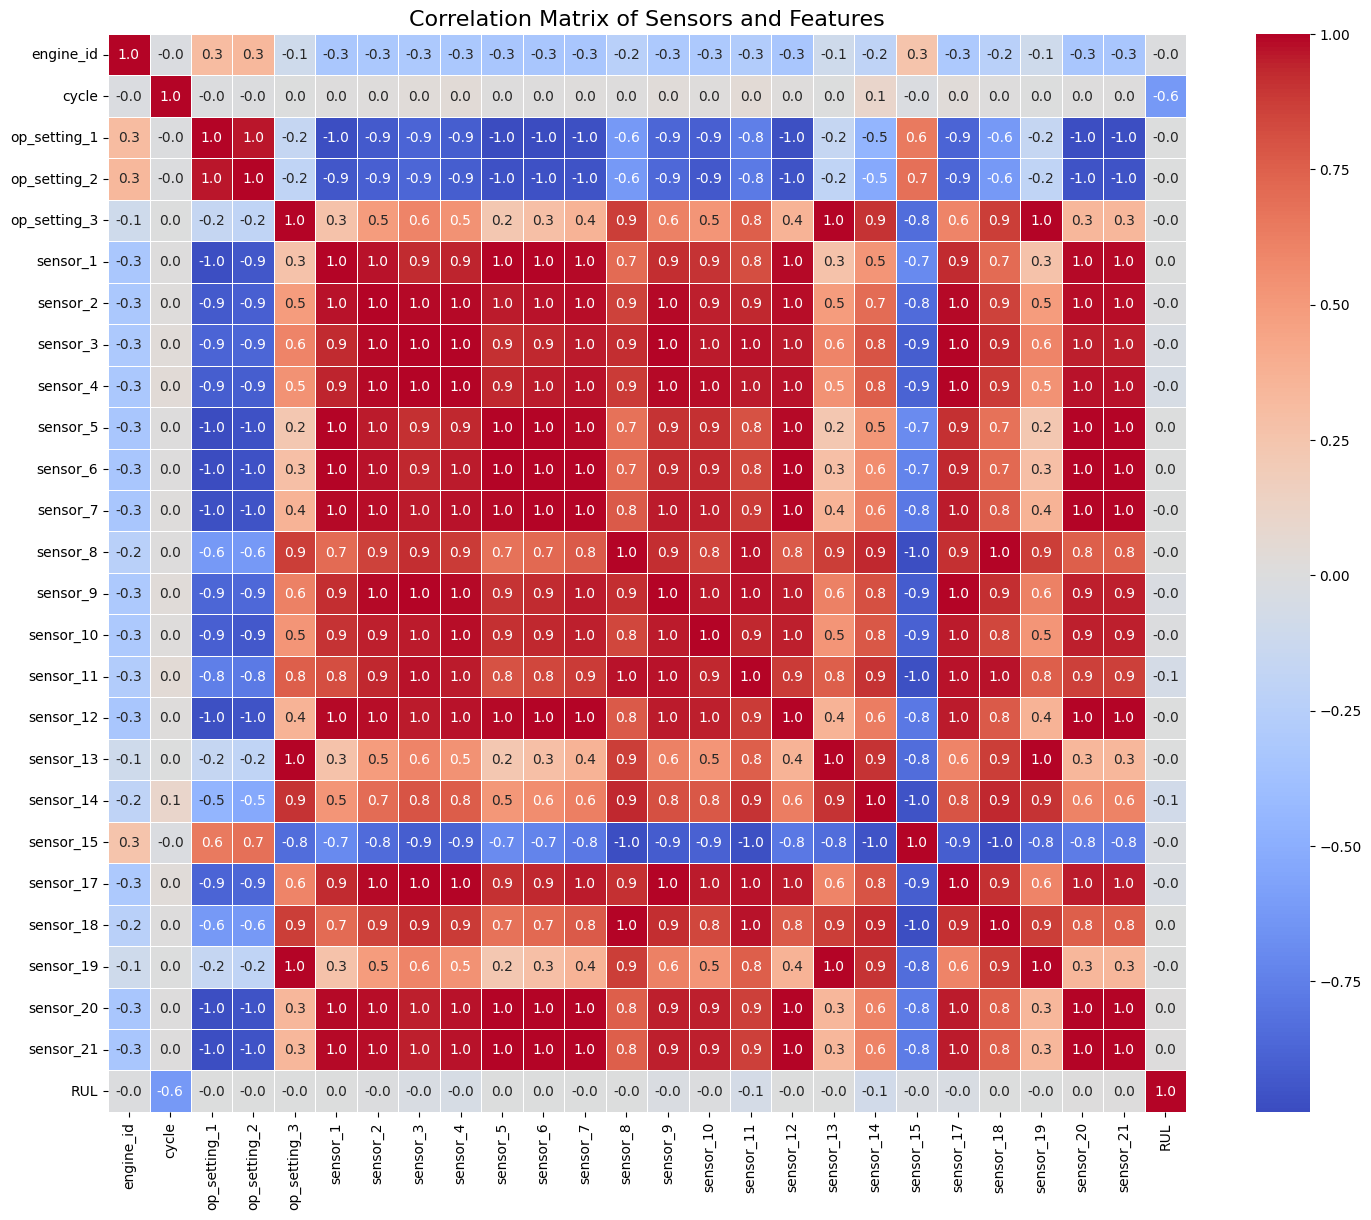

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Remove non-numeric/helper columns
corr_df = train_df.drop(columns=['engine_uid', 'source_file'])

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Plot heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    linewidths=0.5,
    annot=True, fmt=".1f", 
    square=True
)

plt.title("Correlation Matrix of Sensors and Features", fontsize=16)
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

# Get unique engines
unique_engines = train_df['engine_uid'].unique()

# Split engine-wise
train_engines, val_engines = train_test_split(
    unique_engines,
    test_size=0.2,
    random_state=42
)

# Create train and validation sets
train_df = train_df[train_df['engine_uid'].isin(train_engines)].copy()
val_df = train_df[train_df['engine_uid'].isin(val_engines)].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Train engines:", train_df['engine_uid'].nunique())
print("Validation engines:", val_df['engine_uid'].nunique())

Train shape: (129319, 28)
Validation shape: (0, 28)
Train engines: 567
Validation engines: 0


In [15]:
from sklearn.model_selection import train_test_split

# Keep a full copy first
full_df = train_df.copy()

# Unique engines
unique_engines = full_df['engine_uid'].unique()

# Split engine-wise
train_engines, val_engines = train_test_split(
    unique_engines,
    test_size=0.2,
    random_state=42
)

# Create train and validation sets from full_df
train_df = full_df[full_df['engine_uid'].isin(train_engines)].copy()
val_df = full_df[full_df['engine_uid'].isin(val_engines)].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Train engines:", train_df['engine_uid'].nunique())
print("Validation engines:", val_df['engine_uid'].nunique())

Train shape: (103901, 28)
Validation shape: (25418, 28)
Train engines: 453
Validation engines: 114


In [16]:
RUL_CAP = 125

train_df['RUL'] = train_df['RUL'].clip(upper=RUL_CAP)
val_df['RUL'] = val_df['RUL'].clip(upper=RUL_CAP)

train_df['RUL_norm'] = train_df['RUL'] / RUL_CAP
val_df['RUL_norm'] = val_df['RUL'] / RUL_CAP

print("Train RUL max:", train_df['RUL'].max())
print("Val RUL max:", val_df['RUL'].max())
print("Train RUL_norm min/max:", train_df['RUL_norm'].min(), train_df['RUL_norm'].max())
print("Val RUL_norm min/max:", val_df['RUL_norm'].min(), val_df['RUL_norm'].max())

Train RUL max: 125
Val RUL max: 125
Train RUL_norm min/max: 0.0 1.0
Val RUL_norm min/max: 0.0 1.0


In [17]:
# Separate features and target
X_train = train_df.drop(columns=['RUL', 'RUL_norm'])
y_train = train_df['RUL_norm']

X_val = val_df.drop(columns=['RUL', 'RUL_norm'])
y_val = val_df['RUL_norm']

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (103901, 27)
y_train shape: (103901,)
X_val shape: (25418, 27)
y_val shape: (25418,)


In [18]:
from sklearn.preprocessing import StandardScaler

# Feature columns for scaling
feature_cols = [col for col in X_train.columns
                if col not in ['engine_id', 'engine_uid', 'cycle', 'source_file']]

print("Feature count:", len(feature_cols))
print(feature_cols)

scaler = StandardScaler()

X_train[feature_cols] = scaler.fit_transform(X_train[feature_cols])
X_val[feature_cols] = scaler.transform(X_val[feature_cols])

print("Scaling done")
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

Feature count: 23
['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']
Scaling done
X_train shape: (103901, 27)
X_val shape: (25418, 27)


In [19]:
import numpy as np

sequence_length = 30

def create_sequences(X, y, seq_len, engine_col='engine_uid'):
    X_seq = []
    y_seq = []

    for engine in X[engine_col].unique():
        X_engine = X[X[engine_col] == engine].copy()
        y_engine = y[X[engine_col] == engine].copy()

        # Keep only model features
        X_features = X_engine.drop(columns=['engine_id', 'engine_uid', 'cycle', 'source_file']).values
        y_values = y_engine.values

        for i in range(len(X_features) - seq_len + 1):
            X_seq.append(X_features[i:i+seq_len])
            y_seq.append(y_values[i+seq_len-1])

    return np.array(X_seq), np.array(y_seq)

In [20]:
X_train_seq, y_train_seq = create_sequences(X_train, y_train, sequence_length)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, sequence_length)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_val_seq shape:", X_val_seq.shape)
print("y_val_seq shape:", y_val_seq.shape)

X_train_seq shape: (90764, 30, 23)
y_train_seq shape: (90764,)
X_val_seq shape: (22112, 30, 23)
y_val_seq shape: (22112,)


In [21]:
import pickle

# Save sequences
np.save("X_train_seq.npy", X_train_seq)
np.save("y_train_seq.npy", y_train_seq)

np.save("X_val_seq.npy", X_val_seq)
np.save("y_val_seq.npy", y_val_seq)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save feature columns
with open("feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("Saved:")
print("- X_train_seq.npy")
print("- y_train_seq.npy")
print("- X_val_seq.npy")
print("- y_val_seq.npy")
print("- scaler.pkl")
print("- feature_cols.pkl")

Saved:
- X_train_seq.npy
- y_train_seq.npy
- X_val_seq.npy
- y_val_seq.npy
- scaler.pkl
- feature_cols.pkl


In [22]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32)

# Dataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print("Train tensor:", X_train_tensor.shape)
print("Val tensor:", X_val_tensor.shape)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train tensor: torch.Size([90764, 30, 23])
Val tensor: torch.Size([22112, 30, 23])
Train batches: 1419
Val batches: 346


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [24]:
import torch
import torch.nn as nn

class GRURegressor(nn.Module):
    def __init__(self, input_size=23, hidden_size=64, num_layers=3, dropout=0.2):
        super(GRURegressor, self).__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze(1)

model = GRURegressor()
print(model)

GRURegressor(
  (gru): GRU(23, 64, num_layers=3, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [25]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = model.to(device)

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Device: cpu
Train batches: 1419
Validation batches: 346


In [26]:
import copy

epochs = 40

train_losses = []
val_losses = []

best_val_loss = float('inf')
best_epoch = 0
best_model_state = None

for epoch in range(epochs):
    # Training
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()

        # Gradient clipping (IMPORTANT)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("\nBest Validation Loss:", round(best_val_loss, 4))
print("Best Epoch:", best_epoch)

# Load best model
model.load_state_dict(best_model_state)
print(f"Best model from epoch {best_epoch} loaded successfully.")

Epoch 1/40 | Train Loss: 0.1383 | Val Loss: 0.1158
Epoch 2/40 | Train Loss: 0.1049 | Val Loss: 0.1009
Epoch 3/40 | Train Loss: 0.0977 | Val Loss: 0.0896
Epoch 4/40 | Train Loss: 0.0934 | Val Loss: 0.0884
Epoch 5/40 | Train Loss: 0.0887 | Val Loss: 0.0853
Epoch 6/40 | Train Loss: 0.0868 | Val Loss: 0.0877
Epoch 7/40 | Train Loss: 0.0844 | Val Loss: 0.0934
Epoch 8/40 | Train Loss: 0.0835 | Val Loss: 0.0861
Epoch 9/40 | Train Loss: 0.0817 | Val Loss: 0.0812
Epoch 10/40 | Train Loss: 0.0790 | Val Loss: 0.0871
Epoch 11/40 | Train Loss: 0.0766 | Val Loss: 0.0825
Epoch 12/40 | Train Loss: 0.0733 | Val Loss: 0.0826
Epoch 13/40 | Train Loss: 0.0698 | Val Loss: 0.0844
Epoch 14/40 | Train Loss: 0.0667 | Val Loss: 0.0886
Epoch 15/40 | Train Loss: 0.0633 | Val Loss: 0.0840
Epoch 16/40 | Train Loss: 0.0600 | Val Loss: 0.0887
Epoch 17/40 | Train Loss: 0.0577 | Val Loss: 0.0857
Epoch 18/40 | Train Loss: 0.0553 | Val Loss: 0.0882
Epoch 19/40 | Train Loss: 0.0531 | Val Loss: 0.0873
Epoch 20/40 | Train L

In [27]:
torch.save(model.state_dict(), "best_gru_model.pth")
print("Saved: best_gru_model.pth")

Saved: best_gru_model.pth


In [28]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)

        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(outputs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Convert back to actual RUL cycles
y_true_actual = y_true * RUL_CAP
y_pred_actual = y_pred * RUL_CAP

mae = mean_absolute_error(y_true_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_true_actual, y_pred_actual))
r2 = r2_score(y_true_actual, y_pred_actual)

print("GRU Evaluation Metrics")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

GRU Evaluation Metrics
MAE  : 10.1541
RMSE : 16.8519
R2   : 0.8377


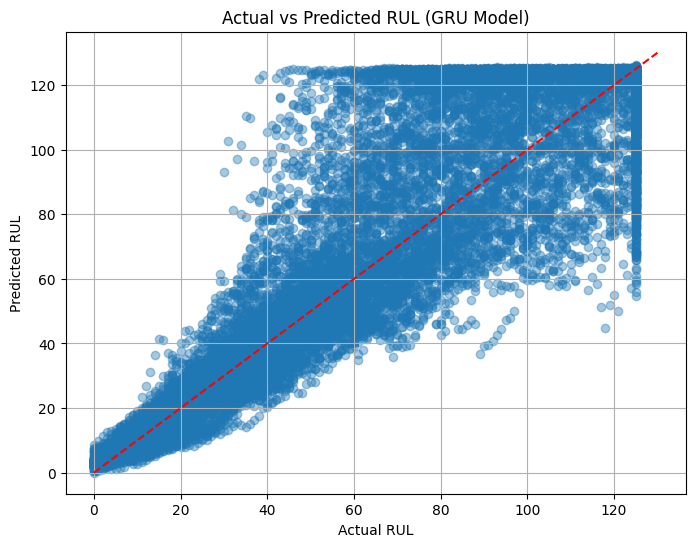

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_true_actual, y_pred_actual, alpha=0.4)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL (GRU Model)")

plt.plot([0, 130], [0, 130], 'r--')  # perfect line

plt.grid(True)
plt.show()

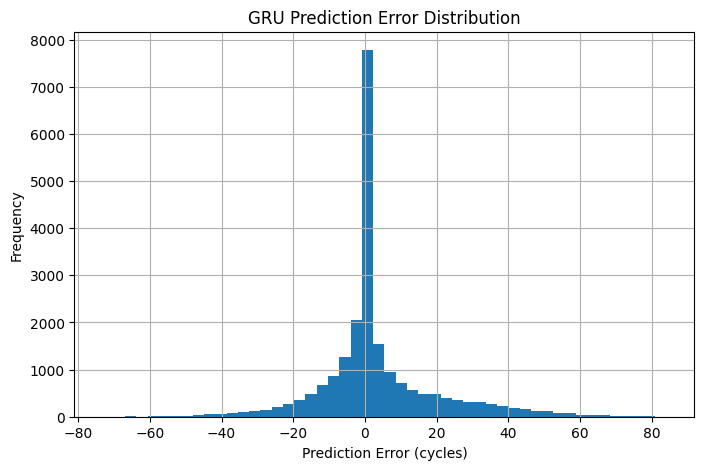

In [30]:
errors = y_pred_actual - y_true_actual

plt.figure(figsize=(8,5))
plt.hist(errors, bins=50)

plt.xlabel("Prediction Error (cycles)")
plt.ylabel("Frequency")
plt.title("GRU Prediction Error Distribution")

plt.grid(True)
plt.show()

In [31]:
import pandas as pd

gru_results = pd.DataFrame({
    'Model': ['GRU'],
    'Best Epoch': [best_epoch],
    'Best Val Loss': [best_val_loss],
    'MAE': [mae],
    'RMSE': [rmse],
    'R2 Score': [r2]
})

gru_loss_df = pd.DataFrame({
    'Epoch': list(range(1, len(train_losses) + 1)),
    'GRU_Train_Loss': train_losses,
    'GRU_Val_Loss': val_losses
})

gru_results.to_csv('gru_evaluation_metrics.csv', index=False)
gru_loss_df.to_csv('gru_loss_history.csv', index=False)

print("Saved:")
print("- gru_evaluation_metrics.csv")
print("- gru_loss_history.csv")
gru_results

Saved:
- gru_evaluation_metrics.csv
- gru_loss_history.csv


,Model,Best Epoch,Best Val Loss,MAE,RMSE,R2 Score
0,GRU,9,0.081164,10.154125,16.851858,0.837685


In [32]:
import torch
import torch.nn as nn

class LSTMRegressor(nn.Module):
    def __init__(self, input_size=23, hidden_size=64, num_layers=3, dropout=0.2):
        super(LSTMRegressor, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze(1)

lstm_model = LSTMRegressor()
print(lstm_model)

LSTMRegressor(
  (lstm): LSTM(23, 64, num_layers=3, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [33]:
import torch.optim as optim

lstm_model = lstm_model.to(device)

criterion = nn.L1Loss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

print("LSTM ready on device:", device)

LSTM ready on device: cpu


In [34]:
import copy

epochs = 20

lstm_train_losses = []
lstm_val_losses = []

best_lstm_val_loss = float('inf')
best_lstm_epoch = 0
best_lstm_model_state = None

for epoch in range(epochs):
    # Training
    lstm_model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = lstm_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)

    # Validation
    lstm_model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = lstm_model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)

    lstm_train_losses.append(train_loss)
    lstm_val_losses.append(val_loss)

    if val_loss < best_lstm_val_loss:
        best_lstm_val_loss = val_loss
        best_lstm_epoch = epoch + 1
        best_lstm_model_state = copy.deepcopy(lstm_model.state_dict())

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("\nBest LSTM Validation Loss:", round(best_lstm_val_loss, 4))
print("Best LSTM Epoch:", best_lstm_epoch)

lstm_model.load_state_dict(best_lstm_model_state)
print(f"Best LSTM model from epoch {best_lstm_epoch} loaded successfully.")

Epoch 1/20 | Train Loss: 0.1432 | Val Loss: 0.1083
Epoch 2/20 | Train Loss: 0.1062 | Val Loss: 0.1040
Epoch 3/20 | Train Loss: 0.1004 | Val Loss: 0.0982
Epoch 4/20 | Train Loss: 0.0947 | Val Loss: 0.0910
Epoch 5/20 | Train Loss: 0.0921 | Val Loss: 0.0923
Epoch 6/20 | Train Loss: 0.0901 | Val Loss: 0.0928
Epoch 7/20 | Train Loss: 0.0876 | Val Loss: 0.0884
Epoch 8/20 | Train Loss: 0.0857 | Val Loss: 0.0926
Epoch 9/20 | Train Loss: 0.0843 | Val Loss: 0.0907
Epoch 10/20 | Train Loss: 0.0827 | Val Loss: 0.0873
Epoch 11/20 | Train Loss: 0.0807 | Val Loss: 0.0868
Epoch 12/20 | Train Loss: 0.0779 | Val Loss: 0.0902
Epoch 13/20 | Train Loss: 0.0761 | Val Loss: 0.0918
Epoch 14/20 | Train Loss: 0.0736 | Val Loss: 0.0953
Epoch 15/20 | Train Loss: 0.0709 | Val Loss: 0.0899
Epoch 16/20 | Train Loss: 0.0683 | Val Loss: 0.0919
Epoch 17/20 | Train Loss: 0.0653 | Val Loss: 0.0914
Epoch 18/20 | Train Loss: 0.0631 | Val Loss: 0.0925
Epoch 19/20 | Train Loss: 0.0607 | Val Loss: 0.0925
Epoch 20/20 | Train L

In [35]:
torch.save(lstm_model.state_dict(), "best_lstm_model.pth")
print("Saved: best_lstm_model.pth")

Saved: best_lstm_model.pth


In [36]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lstm_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = lstm_model(X_batch)

        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(outputs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Convert back to actual RUL cycles
y_true_actual = y_true * RUL_CAP
y_pred_actual = y_pred * RUL_CAP

lstm_mae = mean_absolute_error(y_true_actual, y_pred_actual)
lstm_rmse = np.sqrt(mean_squared_error(y_true_actual, y_pred_actual))
lstm_r2 = r2_score(y_true_actual, y_pred_actual)

print("LSTM Evaluation Metrics")
print(f"MAE  : {lstm_mae:.4f}")
print(f"RMSE : {lstm_rmse:.4f}")
print(f"R2   : {lstm_r2:.4f}")

LSTM Evaluation Metrics
MAE  : 10.8575
RMSE : 17.6976
R2   : 0.8210


In [37]:
import pandas as pd

lstm_results = pd.DataFrame({
    'Model': ['LSTM'],
    'Best Epoch': [best_lstm_epoch],
    'Best Val Loss': [best_lstm_val_loss],
    'MAE': [lstm_mae],
    'RMSE': [lstm_rmse],
    'R2 Score': [lstm_r2]
})

lstm_loss_df = pd.DataFrame({
    'Epoch': list(range(1, len(lstm_train_losses) + 1)),
    'LSTM_Train_Loss': lstm_train_losses,
    'LSTM_Val_Loss': lstm_val_losses
})

comparison_df = pd.DataFrame({
    'Model': ['GRU', 'LSTM'],
    'Best Epoch': [best_epoch, best_lstm_epoch],
    'Best Val Loss': [best_val_loss, best_lstm_val_loss],
    'MAE': [mae, lstm_mae],
    'RMSE': [rmse, lstm_rmse],
    'R2 Score': [r2, lstm_r2]
})

lstm_results.to_csv('lstm_evaluation_metrics.csv', index=False)
lstm_loss_df.to_csv('lstm_loss_history.csv', index=False)
comparison_df.to_csv('model_comparison.csv', index=False)

print("Saved:")
print("- lstm_evaluation_metrics.csv")
print("- lstm_loss_history.csv")
print("- model_comparison.csv")

comparison_df

Saved:
- lstm_evaluation_metrics.csv
- lstm_loss_history.csv
- model_comparison.csv


,Model,Best Epoch,Best Val Loss,MAE,RMSE,R2 Score
0,GRU,9,0.081164,10.154125,16.851858,0.837685
1,LSTM,11,0.086775,10.857533,17.697573,0.820984


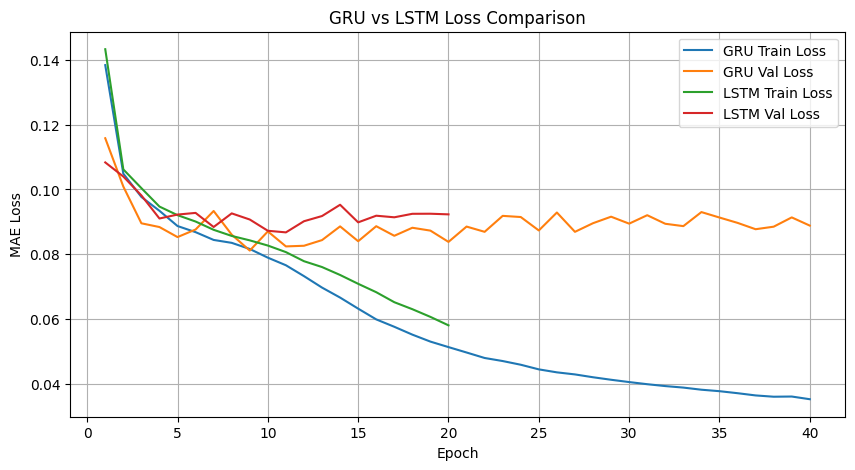

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(range(1, len(train_losses)+1), train_losses, label='GRU Train Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='GRU Val Loss')

plt.plot(range(1, len(lstm_train_losses)+1), lstm_train_losses, label='LSTM Train Loss')
plt.plot(range(1, len(lstm_val_losses)+1), lstm_val_losses, label='LSTM Val Loss')

plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.title('GRU vs LSTM Loss Comparison')

plt.legend()
plt.grid(True)
plt.show()

In [39]:
# GRU predictions again
model.eval()

gru_true = []
gru_pred = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        gru_true.extend(y_batch.cpu().numpy())
        gru_pred.extend(outputs.cpu().numpy())

gru_true = np.array(gru_true)
gru_pred = np.array(gru_pred)

# Convert to actual RUL
gru_true_actual = gru_true * RUL_CAP
gru_pred_actual = gru_pred * RUL_CAP

print("GRU predictions ready")

GRU predictions ready


In [40]:
# LSTM predictions again
lstm_model.eval()

lstm_true = []
lstm_pred = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)

        outputs = lstm_model(X_batch)

        lstm_true.extend(y_batch.cpu().numpy())
        lstm_pred.extend(outputs.cpu().numpy())

lstm_true = np.array(lstm_true)
lstm_pred = np.array(lstm_pred)

# Convert to actual RUL
lstm_true_actual = lstm_true * RUL_CAP
lstm_pred_actual = lstm_pred * RUL_CAP

print("LSTM predictions ready")

LSTM predictions ready


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Average predictions
ensemble_pred_actual = (gru_pred_actual + lstm_pred_actual) / 2

# True values (same for both)
ensemble_true_actual = gru_true_actual

ensemble_mae = mean_absolute_error(ensemble_true_actual, ensemble_pred_actual)
ensemble_rmse = np.sqrt(mean_squared_error(ensemble_true_actual, ensemble_pred_actual))
ensemble_r2 = r2_score(ensemble_true_actual, ensemble_pred_actual)

print("Ensemble Evaluation Metrics")
print(f"MAE  : {ensemble_mae:.4f}")
print(f"RMSE : {ensemble_rmse:.4f}")
print(f"R2   : {ensemble_r2:.4f}")

Ensemble Evaluation Metrics
MAE  : 10.1443
RMSE : 16.6626
R2   : 0.8413


In [42]:
ensemble_results = pd.DataFrame({
    'Model': ['Ensemble (GRU+LSTM)'],
    'MAE': [ensemble_mae],
    'RMSE': [ensemble_rmse],
    'R2 Score': [ensemble_r2]
})

ensemble_results.to_csv('ensemble_metrics.csv', index=False)

print("Saved: ensemble_metrics.csv")
ensemble_results

Saved: ensemble_metrics.csv


,Model,MAE,RMSE,R2 Score
0,Ensemble (GRU+LSTM),10.144281,16.662642,0.841309


In [43]:
import pandas as pd
import os

# Column names
columns = ['engine_id', 'cycle'] + \
          [f'op_setting_{i}' for i in range(1, 4)] + \
          [f'sensor_{i}' for i in range(1, 22)]

test_files = [
    'test_FD001.txt',
    'test_FD002.txt',
    'test_FD003.txt',
    'test_FD004.txt'
]

test_dfs = []

for file in test_files:
    df_test = pd.read_csv(file, sep=r'\s+', header=None)

    # remove extra empty columns if present
    if df_test.shape[1] > 26:
        df_test = df_test.iloc[:, :26]

    df_test.columns = columns
    df_test['source_file'] = os.path.basename(file)
    test_dfs.append(df_test)

test_df = pd.concat(test_dfs, ignore_index=True)

print("Merged test shape:", test_df.shape)
print("Unique source files:", test_df['source_file'].unique())
test_df.head()

Merged test shape: (104897, 27)
Unique source files: ['test_FD001.txt' 'test_FD002.txt' 'test_FD003.txt' 'test_FD004.txt']


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,source_file
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,test_FD001.txt
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,test_FD001.txt
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,test_FD001.txt
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,test_FD001.txt
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,test_FD001.txt


In [44]:
# Keep raw merged test_df unchanged
test_infer_df = test_df.copy()

# Create unique engine id for grouping
test_infer_df['engine_uid'] = test_infer_df['source_file'] + '_' + test_infer_df['engine_id'].astype(str)

# Drop sensor_16 to match training
if 'sensor_16' in test_infer_df.columns:
    test_infer_df = test_infer_df.drop(columns=['sensor_16'])

# Use the same feature columns from training
test_infer_df[feature_cols] = scaler.transform(test_infer_df[feature_cols])

print("Inference test shape:", test_infer_df.shape)
print("Unique test engines:", test_infer_df['engine_uid'].nunique())
print(test_infer_df[['engine_id', 'engine_uid', 'cycle'] + feature_cols[:3]].head())

Inference test shape: (104897, 27)
Unique test engines: 707
   engine_id        engine_uid  cycle  op_setting_1  op_setting_2  \
0          1  test_FD001.txt_1      1     -1.039446     -1.111217   
1          1  test_FD001.txt_1      2     -1.039748     -1.112847   
2          1  test_FD001.txt_1      3     -1.039567     -1.111760   
3          1  test_FD001.txt_1      4     -1.039331     -1.112032   
4          1  test_FD001.txt_1      5     -1.039500     -1.112032   

   op_setting_3  
0       0.34529  
1       0.34529  
2       0.34529  
3       0.34529  
4       0.34529  


In [45]:
import numpy as np
import torch

sequence_length = 30

gru_test_preds = []
lstm_test_preds = []
test_engine_order = []

model.eval()
lstm_model.eval()

for engine in test_infer_df['engine_uid'].unique():
    engine_data = test_infer_df[test_infer_df['engine_uid'] == engine].copy()
    X_features = engine_data[feature_cols].values

    if len(X_features) < sequence_length:
        pad_size = sequence_length - len(X_features)
        pad = np.repeat(X_features[[0]], pad_size, axis=0)
        seq = np.vstack([pad, X_features])
        sequences = np.expand_dims(seq, axis=0)
    else:
        sequences = []
        for i in range(len(X_features) - sequence_length + 1):
            seq = X_features[i:i + sequence_length]
            sequences.append(seq)
        sequences = np.array(sequences)

    seq_tensor = torch.tensor(sequences, dtype=torch.float32).to(device)

    with torch.no_grad():
        gru_preds = model(seq_tensor).cpu().numpy()
        lstm_preds = lstm_model(seq_tensor).cpu().numpy()

    gru_final = gru_preds[-1] * RUL_CAP
    lstm_final = lstm_preds[-1] * RUL_CAP

    gru_test_preds.append(gru_final)
    lstm_test_preds.append(lstm_final)
    test_engine_order.append(engine)

gru_test_preds = np.array(gru_test_preds)
lstm_test_preds = np.array(lstm_test_preds)

print("GRU test preds shape:", gru_test_preds.shape)
print("LSTM test preds shape:", lstm_test_preds.shape)
print("First 5 GRU preds:", gru_test_preds[:5])
print("First 5 LSTM preds:", lstm_test_preds[:5])

GRU test preds shape: (707,)
LSTM test preds shape: (707,)
First 5 GRU preds: [124.81694669 123.81887436  48.52000996  72.85115123 123.25867265]
First 5 LSTM preds: [125.32494962 125.20503998  40.65751284  78.84693146 124.82241541]


In [46]:
# Weighted ensemble: GRU gets more weight because it performed better
ensemble_test_preds = 0.6 * gru_test_preds + 0.4 * lstm_test_preds

print("Ensemble test preds shape:", ensemble_test_preds.shape)
print("First 5 ensemble preds:", ensemble_test_preds[:5])

Ensemble test preds shape: (707,)
First 5 ensemble preds: [125.02014786 124.37334061  45.37501112  75.24946332 123.88416976]


In [47]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

RUL_CAP = 125
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_val_seq = np.load("X_val_seq.npy")
y_val_seq = np.load("y_val_seq.npy")

X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

class GRURegressor(nn.Module):
    def __init__(self, input_size=23, hidden_size=64, num_layers=3, dropout=0.2):
        super(GRURegressor, self).__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out

In [48]:
class GRURegressor(nn.Module):
    def __init__(self, input_size=23, hidden_size=64, num_layers=3, dropout=0.2):
        super(GRURegressor, self).__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]   # take last timestep
        out = self.fc(out)
        return out.squeeze(1)

In [49]:
model = GRURegressor().to(device)
model.load_state_dict(torch.load("best_gru_model.pth", map_location=device))

print("GRU model loaded successfully")

GRU model loaded successfully


In [50]:
model.eval()

y_val_true = []
gru_val_preds = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)

        y_val_true.extend(y_batch.cpu().numpy())
        gru_val_preds.extend(outputs.cpu().numpy())

y_val_true = np.array(y_val_true)
gru_val_preds = np.array(gru_val_preds)

print("GRU validation predictions ready")
print("Shapes:", y_val_true.shape, gru_val_preds.shape)

GRU validation predictions ready
Shapes: (22112,) (22112,)


In [51]:
lstm_model.eval()

lstm_val_preds = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        outputs = lstm_model(X_batch)

        lstm_val_preds.extend(outputs.cpu().numpy())

lstm_val_preds = np.array(lstm_val_preds)

print("LSTM validation predictions ready")
print("Shape:", lstm_val_preds.shape)

LSTM validation predictions ready
Shape: (22112,)


In [52]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size=23, hidden_size=64, num_layers=3, dropout=0.2):
        super(LSTMRegressor, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze(1)

lstm_model = LSTMRegressor().to(device)
lstm_model.load_state_dict(torch.load("best_lstm_model.pth", map_location=device))

print("LSTM model loaded successfully")

LSTM model loaded successfully


In [53]:
# Convert back to actual RUL
y_val_actual = y_val_true * RUL_CAP
gru_val_preds_actual = gru_val_preds * RUL_CAP
lstm_val_preds_actual = lstm_val_preds * RUL_CAP

# Ensemble (weighted)
ensemble_val_preds_actual = 0.6 * gru_val_preds_actual + 0.4 * lstm_val_preds_actual

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# GRU
gru_mae = mean_absolute_error(y_val_actual, gru_val_preds_actual)
gru_rmse = np.sqrt(mean_squared_error(y_val_actual, gru_val_preds_actual))
gru_r2 = r2_score(y_val_actual, gru_val_preds_actual)

# LSTM
lstm_mae = mean_absolute_error(y_val_actual, lstm_val_preds_actual)
lstm_rmse = np.sqrt(mean_squared_error(y_val_actual, lstm_val_preds_actual))
lstm_r2 = r2_score(y_val_actual, lstm_val_preds_actual)

# Ensemble
ensemble_mae = mean_absolute_error(y_val_actual, ensemble_val_preds_actual)
ensemble_rmse = np.sqrt(mean_squared_error(y_val_actual, ensemble_val_preds_actual))
ensemble_r2 = r2_score(y_val_actual, ensemble_val_preds_actual)

In [55]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Model': ['GRU', 'LSTM', 'Ensemble'],
    'MAE': [gru_mae, lstm_mae, ensemble_mae],
    'RMSE': [gru_rmse, lstm_rmse, ensemble_rmse],
    'R2 Score': [gru_r2, lstm_r2, ensemble_r2]
})

comparison_df = comparison_df.round(4)
comparison_df

,Model,MAE,RMSE,R2 Score
0,GRU,10.1541,16.851900,0.8377
1,LSTM,10.8575,17.697599,0.8210
2,Ensemble,10.0848,16.600000,0.8425


In [ ]:
import pandas as pd

# Create results dataframe
results_df = pd.DataFrame({
    'engine_uid': test_engine_order,
    'GRU_RUL': gru_test_preds,
    'LSTM_RUL': lstm_test_preds,
    'Ensemble_RUL': ensemble_test_preds
})
def get_alert(rul):
    if rul <= 30:
        return "CRITICAL"
    elif rul <= 60:
        return "WARNING"
    else:
        return "HEALTHY"

def get_message(rul):
    if rul <= 30:
        return "Immediate maintenance required"
    elif rul <= 60:
        return "Maintenance should be scheduled soon"
    else:
        return "Machine is operating normally"

# Apply alerts
results_df['Alert'] = results_df['Ensemble_RUL'].apply(get_alert)
results_df['Recommendation'] = results_df['Ensemble_RUL'].apply(get_message)

# Sort by most critical first
results_df = results_df.sort_values(by='Ensemble_RUL')

results_df.head(10)

,engine_uid,GRU_RUL,LSTM_RUL,Ensemble_RUL,Alert,Recommendation
215,test_FD002.txt_116,3.453825,2.815285,3.198409,CRITICAL,Immediate maintenance required
237,test_FD002.txt_138,3.638020,3.340180,3.518884,CRITICAL,Immediate maintenance required
106,test_FD002.txt_7,5.126918,3.492381,4.473103,CRITICAL,Immediate maintenance required
190,test_FD002.txt_91,4.115278,5.477185,4.660041,CRITICAL,Immediate maintenance required
202,test_FD002.txt_103,5.443446,4.547731,5.085160,CRITICAL,Immediate maintenance required
233,test_FD002.txt_134,6.036456,4.533119,5.435122,CRITICAL,Immediate maintenance required
201,test_FD002.txt_102,7.716670,2.600881,5.670355,CRITICAL,Immediate maintenance required
631,test_FD004.txt_173,7.041605,4.015207,5.831046,CRITICAL,Immediate maintenance required
309,test_FD002.txt_210,5.856847,6.411192,6.078585,CRITICAL,Immediate maintenance required
33,test_FD001.txt_34,6.212256,6.689227,6.403044,CRITICAL,Immediate maintenance required


In [57]:
# Clip predictions to valid RUL range
gru_test_preds = np.clip(gru_test_preds, 0, RUL_CAP)
lstm_test_preds = np.clip(lstm_test_preds, 0, RUL_CAP)
ensemble_test_preds = np.clip(ensemble_test_preds, 0, RUL_CAP)

# Recreate results
results_df = pd.DataFrame({
    'engine_uid': test_engine_order,
    'GRU_RUL': gru_test_preds,
    'LSTM_RUL': lstm_test_preds,
    'Ensemble_RUL': ensemble_test_preds
})

# Alert logic (same)
def get_alert(rul):
    if rul <= 30:
        return "CRITICAL"
    elif rul <= 60:
        return "WARNING"
    else:
        return "HEALTHY"

def get_message(rul):
    if rul <= 30:
        return "Immediate maintenance required"
    elif rul <= 60:
        return "Maintenance should be scheduled soon"
    else:
        return "Machine is operating normally"

results_df['Alert'] = results_df['Ensemble_RUL'].apply(get_alert)
results_df['Recommendation'] = results_df['Ensemble_RUL'].apply(get_message)

# Sort again
results_df = results_df.sort_values(by='Ensemble_RUL')

results_df.head(10)

,engine_uid,GRU_RUL,LSTM_RUL,Ensemble_RUL,Alert,Recommendation
215,test_FD002.txt_116,3.453825,2.815285,3.198409,CRITICAL,Immediate maintenance required
237,test_FD002.txt_138,3.638020,3.340180,3.518884,CRITICAL,Immediate maintenance required
106,test_FD002.txt_7,5.126918,3.492381,4.473103,CRITICAL,Immediate maintenance required
190,test_FD002.txt_91,4.115278,5.477185,4.660041,CRITICAL,Immediate maintenance required
202,test_FD002.txt_103,5.443446,4.547731,5.085160,CRITICAL,Immediate maintenance required
233,test_FD002.txt_134,6.036456,4.533119,5.435122,CRITICAL,Immediate maintenance required
201,test_FD002.txt_102,7.716670,2.600881,5.670355,CRITICAL,Immediate maintenance required
631,test_FD004.txt_173,7.041605,4.015207,5.831046,CRITICAL,Immediate maintenance required
309,test_FD002.txt_210,5.856847,6.411192,6.078585,CRITICAL,Immediate maintenance required
33,test_FD001.txt_34,6.212256,6.689227,6.403044,CRITICAL,Immediate maintenance required


In [58]:
results_df['GRU_RUL'] = results_df['GRU_RUL'].round(2)
results_df['LSTM_RUL'] = results_df['LSTM_RUL'].round(2)
results_df['Ensemble_RUL'] = results_df['Ensemble_RUL'].round(2)

results_df.head(10)

,engine_uid,GRU_RUL,LSTM_RUL,Ensemble_RUL,Alert,Recommendation
215,test_FD002.txt_116,3.45,2.82,3.20,CRITICAL,Immediate maintenance required
237,test_FD002.txt_138,3.64,3.34,3.52,CRITICAL,Immediate maintenance required
106,test_FD002.txt_7,5.13,3.49,4.47,CRITICAL,Immediate maintenance required
190,test_FD002.txt_91,4.12,5.48,4.66,CRITICAL,Immediate maintenance required
202,test_FD002.txt_103,5.44,4.55,5.09,CRITICAL,Immediate maintenance required
233,test_FD002.txt_134,6.04,4.53,5.44,CRITICAL,Immediate maintenance required
201,test_FD002.txt_102,7.72,2.60,5.67,CRITICAL,Immediate maintenance required
631,test_FD004.txt_173,7.04,4.02,5.83,CRITICAL,Immediate maintenance required
309,test_FD002.txt_210,5.86,6.41,6.08,CRITICAL,Immediate maintenance required
33,test_FD001.txt_34,6.21,6.69,6.40,CRITICAL,Immediate maintenance required


In [59]:
print(results_df['Alert'].value_counts())

Alert
HEALTHY     444
CRITICAL    158
WARNING     105
Name: count, dtype: int64


In [60]:
results_df['Ensemble_RUL'].describe()

count    707.000000
mean      79.244229
std       43.987656
min        3.200000
25%       34.710000
50%       92.490000
75%      124.360000
max      125.000000
Name: Ensemble_RUL, dtype: float64

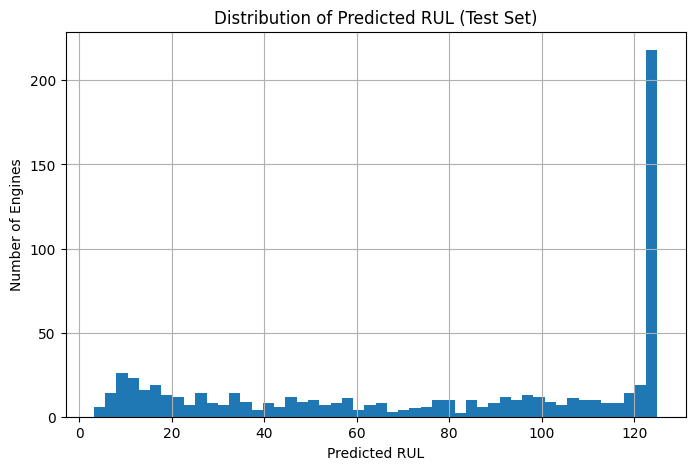

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(results_df['Ensemble_RUL'], bins=50)

plt.xlabel("Predicted RUL")
plt.ylabel("Number of Engines")
plt.title("Distribution of Predicted RUL (Test Set)")

plt.grid(True)
plt.show()

In [62]:
print("25th percentile:", np.percentile(results_df['Ensemble_RUL'], 25))
print("50th percentile:", np.percentile(results_df['Ensemble_RUL'], 50))
print("75th percentile:", np.percentile(results_df['Ensemble_RUL'], 75))

25th percentile: 34.709999999999994
50th percentile: 92.49
75th percentile: 124.36


In [63]:
# Get thresholds
low_thresh = np.percentile(results_df['Ensemble_RUL'], 25)
high_thresh = np.percentile(results_df['Ensemble_RUL'], 60)

print("Low threshold:", low_thresh)
print("High threshold:", high_thresh)

# New alert logic
def get_alert_adaptive(rul):
    if rul <= low_thresh:
        return "CRITICAL"
    elif rul <= high_thresh:
        return "WARNING"
    else:
        return "HEALTHY"

def get_message_adaptive(rul):
    if rul <= low_thresh:
        return "Immediate maintenance required"
    elif rul <= high_thresh:
        return "Maintenance should be scheduled soon"
    else:
        return "Machine is operating normally"

# Apply new alerts
results_df['Adaptive_Alert'] = results_df['Ensemble_RUL'].apply(get_alert_adaptive)
results_df['Adaptive_Message'] = results_df['Ensemble_RUL'].apply(get_message_adaptive)

results_df.head()

Low threshold: 34.709999999999994
High threshold: 109.416


,engine_uid,GRU_RUL,LSTM_RUL,Ensemble_RUL,Alert,Recommendation,Adaptive_Alert,Adaptive_Message
215,test_FD002.txt_116,3.45,2.82,3.20,CRITICAL,Immediate maintenance required,CRITICAL,Immediate maintenance required
237,test_FD002.txt_138,3.64,3.34,3.52,CRITICAL,Immediate maintenance required,CRITICAL,Immediate maintenance required
106,test_FD002.txt_7,5.13,3.49,4.47,CRITICAL,Immediate maintenance required,CRITICAL,Immediate maintenance required
190,test_FD002.txt_91,4.12,5.48,4.66,CRITICAL,Immediate maintenance required,CRITICAL,Immediate maintenance required
202,test_FD002.txt_103,5.44,4.55,5.09,CRITICAL,Immediate maintenance required,CRITICAL,Immediate maintenance required


In [64]:
print("Old Alert Distribution:")
print(results_df['Alert'].value_counts())

print("\nNew Adaptive Alert Distribution:")
print(results_df['Adaptive_Alert'].value_counts())

Old Alert Distribution:
Alert
HEALTHY     444
CRITICAL    158
WARNING     105
Name: count, dtype: int64

New Adaptive Alert Distribution:
Adaptive_Alert
HEALTHY     283
WARNING     247
CRITICAL    177
Name: count, dtype: int64


In [65]:
def get_alert_final(rul):
    if rul <= 35:
        return "CRITICAL"
    elif rul <= 85:
        return "WARNING"
    else:
        return "HEALTHY"

def get_message_final(rul):
    if rul <= 35:
        return "Immediate maintenance required"
    elif rul <= 85:
        return "Maintenance should be scheduled soon"
    else:
        return "Machine is operating normally"

results_df['Final_Alert'] = results_df['Ensemble_RUL'].apply(get_alert_final)
results_df['Final_Message'] = results_df['Ensemble_RUL'].apply(get_message_final)

results_df.head()

,engine_uid,GRU_RUL,LSTM_RUL,Ensemble_RUL,Alert,Recommendation,Adaptive_Alert,Adaptive_Message,Final_Alert,Final_Message
215,test_FD002.txt_116,3.45,2.82,3.20,CRITICAL,Immediate maintenance required,CRITICAL,Immediate maintenance required,CRITICAL,Immediate maintenance required
237,test_FD002.txt_138,3.64,3.34,3.52,CRITICAL,Immediate maintenance required,CRITICAL,Immediate maintenance required,CRITICAL,Immediate maintenance required
106,test_FD002.txt_7,5.13,3.49,4.47,CRITICAL,Immediate maintenance required,CRITICAL,Immediate maintenance required,CRITICAL,Immediate maintenance required
190,test_FD002.txt_91,4.12,5.48,4.66,CRITICAL,Immediate maintenance required,CRITICAL,Immediate maintenance required,CRITICAL,Immediate maintenance required
202,test_FD002.txt_103,5.44,4.55,5.09,CRITICAL,Immediate maintenance required,CRITICAL,Immediate maintenance required,CRITICAL,Immediate maintenance required


In [66]:
print(results_df['Final_Alert'].value_counts())

Final_Alert
HEALTHY     382
CRITICAL    181
WARNING     144
Name: count, dtype: int64


In [67]:
# Save final results (use FINAL alert if available)

# Prefer Final_Alert if exists
if 'Final_Alert' in results_df.columns:
    save_df = results_df.copy()
    save_df['Alert'] = save_df['Final_Alert']
    save_df['Recommendation'] = results_df['Final_Message']
else:
    save_df = results_df.copy()

# Save file
save_df.to_csv("final_test_alert_results.csv", index=False)

print("Saved: final_test_alert_results.csv")

Saved: final_test_alert_results.csv


In [68]:
import pandas as pd

rul_files = [
    'RUL_FD001.txt',
    'RUL_FD002.txt',
    'RUL_FD003.txt',
    'RUL_FD004.txt'
]

rul_dfs = []

for file in rul_files:
    df_rul = pd.read_csv(file, sep=r'\s+', header=None)
    df_rul = df_rul.iloc[:, :1]
    df_rul.columns = ['true_rul']
    df_rul['source_file'] = file.replace('RUL', 'test')
    rul_dfs.append(df_rul)

true_rul_df = pd.concat(rul_dfs, ignore_index=True)

# Match engine order
pred_source_files = [engine.rsplit('_', 1)[0] for engine in test_engine_order]

pred_df = pd.DataFrame({
    'engine_uid': test_engine_order,
    'source_file': pred_source_files,
    'pred_rul': ensemble_test_preds
})

pred_df['engine_no'] = pred_df.groupby('source_file').cumcount() + 1
true_rul_df['engine_no'] = true_rul_df.groupby('source_file').cumcount() + 1

eval_df = pd.merge(pred_df, true_rul_df, on=['source_file', 'engine_no'], how='inner')

eval_df.head()

,engine_uid,source_file,pred_rul,engine_no,true_rul
0,test_FD001.txt_1,test_FD001.txt,125.000000,1,112
1,test_FD001.txt_2,test_FD001.txt,124.373341,2,98
2,test_FD001.txt_3,test_FD001.txt,45.375011,3,69
3,test_FD001.txt_4,test_FD001.txt,75.249463,4,82
4,test_FD001.txt_5,test_FD001.txt,123.884170,5,91


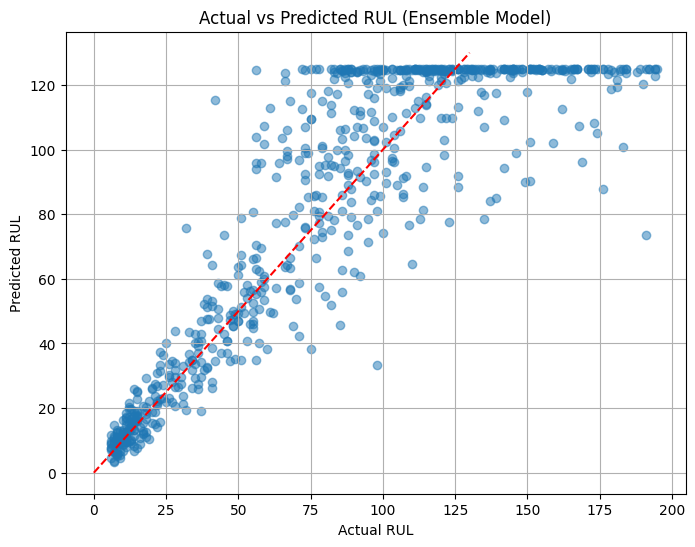

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(eval_df['true_rul'], eval_df['pred_rul'], alpha=0.5)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL (Ensemble Model)")

# perfect prediction line
plt.plot([0, 130], [0, 130], 'r--')

plt.grid(True)
plt.show()

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_test = mean_absolute_error(eval_df['true_rul'], eval_df['pred_rul'])
rmse_test = np.sqrt(mean_squared_error(eval_df['true_rul'], eval_df['pred_rul']))

print("Test MAE:", mae_test)
print("Test RMSE:", rmse_test)

Test MAE: 17.08565689397836
Test RMSE: 24.592592224609383


In [71]:
 pip install streamlit


[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
streamlit run dashboard.py